# Sentiment Analysis IKN — Fine-tuning IndoBERT

Notebook ini melanjutkan dari `eda_preprocessing.ipynb`.

**Model yang digunakan:** `indobenchmark/indobert-base-p1` — BERT yang di-pretrain pada korpus Bahasa Indonesia.

**Pipeline:**
1. Install & import library
2. Load & encode data
3. Split dataset
4. Tokenisasi dengan IndoBERT Tokenizer
5. Buat Dataset & DataLoader
6. Definisi model
7. Training loop
8. Evaluasi (accuracy, classification report, confusion matrix)
9. Simpan model
10. Inference / prediksi teks baru

## 1. Install Library
> Jalankan cell ini sekali saja. Jika sudah terinstall, bisa di-skip.

In [ ]:
!pip install transformers datasets torch scikit-learn seaborn matplotlib --quiet

You should consider upgrading via the 'c:\users\lenovo\wslp\pba2026-sentimentteam\venv\scripts\python.exe -m pip install --upgrade pip' command.


## 2. Import Library

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

# Cek device: GPU atau CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device yang digunakan: {device}')

Device yang digunakan: cpu


## 3. Load Data & Encode Label

In [ ]:
df = pd.read_csv('../data/clean_data.csv')

# Hapus kolom bantu jika ada
if 'text_length' in df.columns:
    df = df.drop(columns=['text_length'])

df = df.dropna(subset=['text', 'label'])
df = df.reset_index(drop=True)

print(f'Total data: {len(df)}')
print(df['label'].value_counts())
df.head()

Total data: 1472
label
negatif    780
positif    692
Name: count, dtype: int64


,text,label
0,ikn ibukota koruptor nepotisme,negatif
1,sy mau tanya ikn itu untuk apa trs yg menempat...,negatif
2,bapak skolahin anak nya yg setinggi nnti bsa n...,negatif
3,wacana belim ada kesitu realnya dan faktanya a...,negatif
4,follow ig ikn pak udh dr lama kq buka lowongan...,negatif


In [6]:
# Encode label: negatif=0, positif=1
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

print('Mapping label:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} -> {i}')

Mapping label:
  negatif -> 0
  positif -> 1


## 4. Split Dataset (Train / Validation / Test)

In [ ]:
X = df['text'].values
y = df['label_enc'].values

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train : {len(X_train)} samples')
print(f'Val   : {len(X_val)} samples')
print(f'Test  : {len(X_test)} samples')

Train : 1030 samples
Val   : 221 samples
Test  : 221 samples


## 5. Load Tokenizer IndoBERT

In [8]:
MODEL_NAME = 'indobenchmark/indobert-base-p1'
MAX_LEN    = 128   # panjang token maksimal (sesuaikan RAM/VRAM)
BATCH_SIZE = 16    # kurangi ke 8 jika memory terbatas
EPOCHS     = 5
LR         = 2e-5

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer berhasil dimuat.')

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Tokenizer berhasil dimuat.


## 6. Custom Dataset Class

In [9]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = SentimentDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = SentimentDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = SentimentDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print('Dataset & DataLoader siap.')

Dataset & DataLoader siap.


## 7. Load Model BERT

In [10]:
NUM_LABELS = len(le.classes_)   # 2: negatif, positif

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model = model.to(device)
print(f'Model dimuat ke {device}.')

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model dimuat ke cpu.


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

## 8. Optimizer & Scheduler

In [11]:
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Total steps: {total_steps} | Warmup steps: {warmup_steps}')

Total steps: 325 | Warmup steps: 32


## 9. Helper Function: Evaluasi

In [12]:
def evaluate(model, loader):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_preds, all_labels

## 10. Training Loop

In [14]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_train_loss = 0
    all_train_preds, all_train_labels = [], []

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()

        # Gradient clipping untuk stabilitas
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

        if (step + 1) % 20 == 0:
            print(f'  Epoch {epoch} | Step {step+1}/{len(train_loader)} | Loss: {loss.item():.4f}')

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc      = accuracy_score(all_train_labels, all_train_preds)

    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'\nEpoch {epoch}/{EPOCHS}')
    print(f'  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'  Val   Loss: {val_loss:.4f}  | Val   Acc: {val_acc:.4f}')

    # Simpan model terbaik
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '../best_bert_model.pt')
        print(f'  ✅ Model terbaik disimpan (val_acc={best_val_acc:.4f})')
    print('-' * 50)

  Epoch 1 | Step 20/65 | Loss: 0.3681
  Epoch 1 | Step 40/65 | Loss: 0.5242
  Epoch 1 | Step 60/65 | Loss: 0.2276

Epoch 1/5
  Train Loss: 0.1971 | Train Acc: 0.9252
  Val   Loss: 0.4621  | Val   Acc: 0.8507
  ✅ Model terbaik disimpan (val_acc=0.8507)
--------------------------------------------------
  Epoch 2 | Step 20/65 | Loss: 0.0024
  Epoch 2 | Step 40/65 | Loss: 0.0049
  Epoch 2 | Step 60/65 | Loss: 0.0638

Epoch 2/5
  Train Loss: 0.0734 | Train Acc: 0.9816
  Val   Loss: 0.8053  | Val   Acc: 0.8281
--------------------------------------------------
  Epoch 3 | Step 20/65 | Loss: 0.0018
  Epoch 3 | Step 40/65 | Loss: 0.0030
  Epoch 3 | Step 60/65 | Loss: 0.0012

Epoch 3/5
  Train Loss: 0.0422 | Train Acc: 0.9883
  Val   Loss: 0.8408  | Val   Acc: 0.8326
--------------------------------------------------
  Epoch 4 | Step 20/65 | Loss: 0.0019
  Epoch 4 | Step 40/65 | Loss: 0.0012
  Epoch 4 | Step 60/65 | Loss: 0.0105

Epoch 4/5
  Train Loss: 0.0136 | Train Acc: 0.9961
  Val   Loss:

## 11. Plot Training History

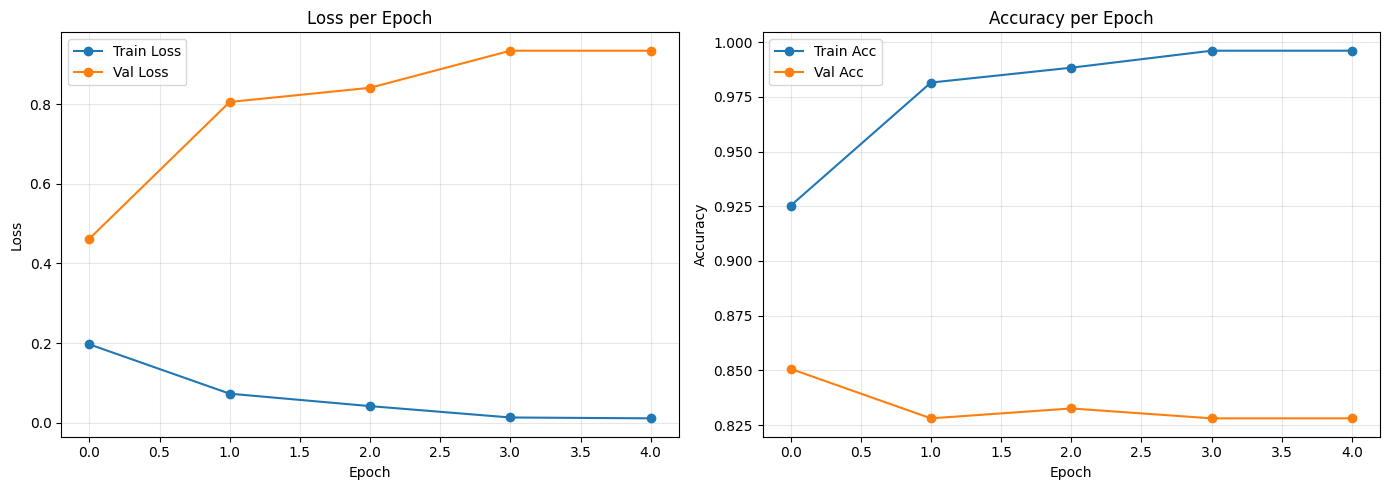

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'],   label='Val Loss',   marker='o')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'],   label='Val Acc',   marker='o')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../training_history.png', dpi=150)
plt.show()

## 12. Evaluasi pada Test Set

In [16]:
# Load model terbaik
model.load_state_dict(torch.load('../best_bert_model.pt', map_location=device))

test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader)

print(f'Test Loss : {test_loss:.4f}')
print(f'Test Acc  : {test_acc:.4f}\n')
print('Classification Report:')
print(classification_report(test_labels, test_preds, target_names=le.classes_))

Test Loss : 0.3376
Test Acc  : 0.8959

Classification Report:
              precision    recall  f1-score   support

     negatif       0.86      0.96      0.91       117
     positif       0.95      0.83      0.88       104

    accuracy                           0.90       221
   macro avg       0.90      0.89      0.89       221
weighted avg       0.90      0.90      0.90       221



## 13. Confusion Matrix

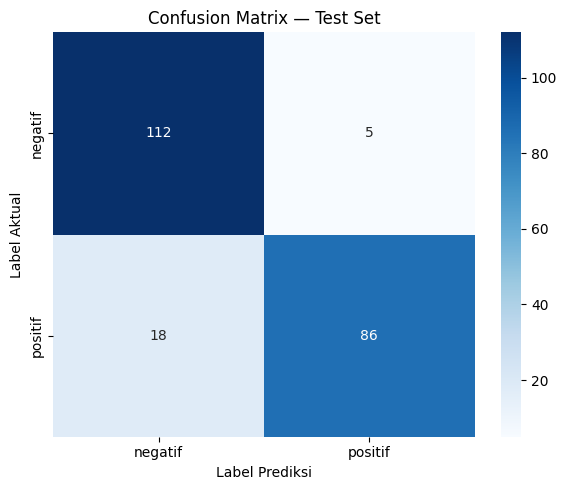

In [17]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.savefig('../confusion_matrix.png', dpi=150)
plt.show()

## 14. Simpan Tokenizer & Model Lengkap

In [18]:
import os
os.makedirs('../indobert_sentiment', exist_ok=True)

model.save_pretrained('../indobert_sentiment')
tokenizer.save_pretrained('../indobert_sentiment')

import json
label_map = {i: cls for i, cls in enumerate(le.classes_)}
with open('../indobert_sentiment/label_map.json', 'w') as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

print('✅ Model, tokenizer, dan label map tersimpan di ../indobert_sentiment/')

✅ Model, tokenizer, dan label map tersimpan di ../indobert_sentiment/


## 15. Inference — Prediksi Teks Baru

In [19]:
def predict_sentiment(texts, model, tokenizer, label_map, max_len=128):
    """
    texts: str atau list of str
    Mengembalikan list of dict {'text', 'label', 'confidence'}
    """
    if isinstance(texts, str):
        texts = [texts]

    model.eval()
    results = []

    for text in texts:
        encoding = tokenizer(
            text.lower(),
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs   = torch.softmax(outputs.logits, dim=1)
            pred    = torch.argmax(probs, dim=1).item()
            conf    = probs[0][pred].item()

        results.append({
            'text'      : text,
            'label'     : label_map[pred],
            'confidence': round(conf, 4)
        })

    return results


# ── Contoh prediksi ──────────────────────────────────────────────
label_map = {i: cls for i, cls in enumerate(le.classes_)}

sample_texts = [
    "ikn adalah proyek ambisius yang akan memajukan indonesia",
    "pembangunan ikn hanya buang uang rakyat",
    "semoga ikn bisa selesai dan bermanfaat bagi seluruh warga"
]

predictions = predict_sentiment(sample_texts, model, tokenizer, label_map)

result_df = pd.DataFrame(predictions)
print(result_df.to_string(index=False))

                                                     text   label  confidence
 ikn adalah proyek ambisius yang akan memajukan indonesia positif      0.9608
                  pembangunan ikn hanya buang uang rakyat negatif      0.9933
semoga ikn bisa selesai dan bermanfaat bagi seluruh warga positif      0.9928
